In [1]:
# %%
import pandas as pd  # 导入 pandas 模块，用于数据处理
import seaborn as sns  # 导入 seaborn 模块，用于绘制统计图表
import matplotlib.pyplot as plt  # 导入 matplotlib.pyplot 模块，用于绘图

In [2]:
# %%
df = pd.read_csv('douban_movie_reviews.csv')
df

,URL,Review,Rating
0,https://movie.douban.com/subject/1292052/,恐惧让你沦为囚犯，希望让你重获自由。——《肖申克的救赎》,5.0
1,https://movie.douban.com/subject/1292052/,当年的奥斯卡颁奖礼上，被如日中天的《阿甘正传》掩盖了它的光彩，而随着时间的推移，这部电影在越...,5.0
2,https://movie.douban.com/subject/1292052/,策划了19年的私奔……,5.0
3,https://movie.douban.com/subject/1292052/,关于希望最强有力的注释。,5.0
4,https://movie.douban.com/subject/1292052/,“这是一部男人必看的电影。”人人都这么说。但单纯从性别区分，就会让这电影变狭隘。《肖申克的救...,5.0
...,...,...,...
14014,https://movie.douban.com/subject/27113517/,港风台湾片。导演是有多喜欢玩解密和反转，布局真是大漏洞。一个努力讲故事但故事没意思，努力做效...,2.0
14015,https://movie.douban.com/subject/27113517/,未成年演员演强奸戏，还有那么多人洗，有够恶心。,1.0
14016,https://movie.douban.com/subject/27113517/,敘事焦點的遊移再加上怪怪的剪輯節奏讓故事有點拎不清，慢鏡的部分讓人跳戲，劇本的設置也有點幼稚,2.0
14017,https://movie.douban.com/subject/27113517/,以扑面而来的电影质感（表演剪接节奏等）而言，这片就已经比大佛活生生地少了一星以上……,2.0


In [8]:
# %%
# 读取 CSV 文件中的数据到 DataFrame
df = pd.read_csv('douban_movie_reviews.csv')
# 过滤掉评分为'无评分'的行
df = df[df['Rating'] != '无评分']
# 删除包含缺失值的行，针对'Rating'列
df.dropna(subset=['Rating'], inplace=True)
# 先确保 Review 列是字符串类型
df['Review'] = df['Review'].astype(str)
# 再计算评论长度
df['Review_length'] = df['Review'].apply(len)

In [9]:
# %%
df['Rating'].value_counts()

Rating
3.0    4294
2.0    3553
5.0    2864
4.0    1733
1.0    1496
Name: count, dtype: int64

In [10]:
# %%
# 计算评论长度的 95% 分位数
length_quantile_95 = df['Review_length'].quantile(0.95)
print(length_quantile_95)


200.0


c:\StudyAPP\Anaconda\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


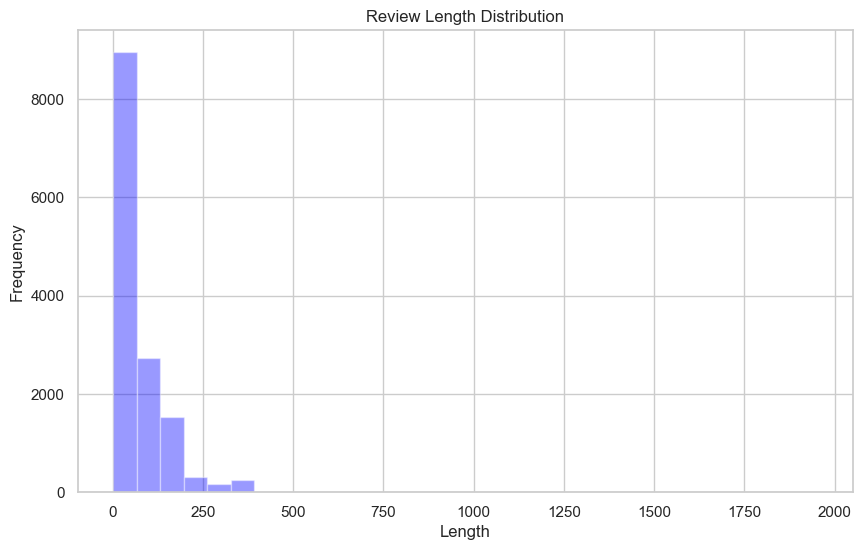

In [11]:
# %%
###查看Review的字符长度分布
# 设置 seaborn 的样式为白色网格
sns.set(style="whitegrid")
# 创建一个新的图表，指定尺寸为(10, 6)
plt.figure(figsize=(10, 6))
# 绘制评论长度的直方图
sns.distplot(df['Review_length'], kde=False, bins=30, color='blue')  # kde=False 表示不显示核密度估计曲线，bins 控制柱状图的数量
# 设置图表标题、x轴标签和y轴标签
plt.title('Review Length Distribution')
plt.xlabel('Length')
plt.ylabel('Frequency')
# 显示图表
plt.show()


In [12]:
# %%
# 定义映射字典：原始分数 -> 新标签
rating_map = {1: 1, 2: 1, 3: 2, 4: 3, 5: 4}

In [13]:
# 使用 map() 方法转换 Rating 列
df['Rating'] = df['Rating'].map(rating_map)

# %%
df = df[['Review', 'Rating']]

# %%
# 保存到新的 CSV 文件
df.to_csv('clean_data.csv', index=False, encoding='utf-8')

# %%